# Análisis Exploratorio de Datos - Censo Uruguay 2023
## Dataset: Hogares

Este notebook realiza el EDA del dataset de hogares del Censo Uruguay 2023,
limpia los datos y genera un CSV procesado listo para la aplicación Streamlit.

## 1. Carga y Estructura

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset raw
df_raw = pd.read_csv('../data/raw/hogares_ext_26_02.csv', low_memory=False)

print(f'Dimensiones del dataset: {df_raw.shape}')
print(f'Filas: {df_raw.shape[0]:,}  |  Columnas: {df_raw.shape[1]}')

Dimensiones del dataset: (1255204, 39)
Filas: 1,255,204  |  Columnas: 39


In [2]:
# Vista preliminar
df_raw.head()

,Unnamed: 0,DIRECCION_ID,DEPARTAMENTO,LOCALIDAD,VIVID,HOGID,REGION_4,AREA,MUNICIPIO_PAIS,TIPO_MUNICIPIO_PAIS,...,HOGCE28,HOGCE11,HOGCE22,HOGCE12_1,HOGCE13,HOGMA01_1,HOGMA01_1_1,HOGMA01_2,HOGMA01_2_1,HOGPR01_CON_RRAA
0,1,1000001,1,20,1,1,1,1,Municipio B,C,...,1,1,1,2,0,2,7777,2,7777,2
1,2,1000002,1,20,1,1,1,1,Municipio B,C,...,1,1,2,2,1,2,7777,2,7777,2
2,3,1000003,1,20,1,1,1,1,Municipio B,C,...,1,1,1,2,1,1,2,1,2,2
3,4,1000004,1,20,1,1,1,1,Municipio B,C,...,1,1,2,2,0,2,7777,2,7777,1
4,5,1000005,1,20,1,1,1,1,Municipio B,C,...,1,1,1,2,1,2,7777,2,7777,4


In [3]:
# Tipos de datos
df_raw.dtypes

Unnamed: 0             int64
DIRECCION_ID           int64
DEPARTAMENTO           int64
LOCALIDAD              int64
VIVID                  int64
HOGID                  int64
REGION_4               int64
AREA                   int64
MUNICIPIO_PAIS           str
TIPO_MUNICIPIO_PAIS      str
VIVVO00                int64
HOGTE01                int64
HOGTE02                int64
HOGTE03                int64
HOGSH01                int64
HOGSH02                int64
HOGSH03                int64
HOGSC01                int64
HOGHD00                int64
HOGHD01                int64
HOGSC02                int64
HOGCA01                int64
HOGRS01                int64
HOGCE27                int64
HOGCE26                int64
HOGCE03                int64
HOGCE04                int64
HOGCE17                int64
HOGCE17_1              int64
HOGCE28                int64
HOGCE11                int64
HOGCE22                int64
HOGCE12_1              int64
HOGCE13                int64
HOGMA01_1     

In [4]:
# Valores nulos originales
print('Valores nulos por columna:')
df_raw.isnull().sum()

Valores nulos por columna:


Unnamed: 0             0
DIRECCION_ID           0
DEPARTAMENTO           0
LOCALIDAD              0
VIVID                  0
HOGID                  0
REGION_4               0
AREA                   0
MUNICIPIO_PAIS         4
TIPO_MUNICIPIO_PAIS    4
VIVVO00                0
HOGTE01                0
HOGTE02                0
HOGTE03                0
HOGSH01                0
HOGSH02                0
HOGSH03                0
HOGSC01                0
HOGHD00                0
HOGHD01                0
HOGSC02                0
HOGCA01                0
HOGRS01                0
HOGCE27                0
HOGCE26                0
HOGCE03                0
HOGCE04                0
HOGCE17                0
HOGCE17_1              0
HOGCE28                0
HOGCE11                0
HOGCE22                0
HOGCE12_1              0
HOGCE13                0
HOGMA01_1              0
HOGMA01_1_1            0
HOGMA01_2              0
HOGMA01_2_1            0
HOGPR01_CON_RRAA       0
dtype: int64

In [5]:
# Estadísticas descriptivas iniciales
df_raw.describe()

,Unnamed: 0,DIRECCION_ID,DEPARTAMENTO,LOCALIDAD,VIVID,HOGID,REGION_4,AREA,VIVVO00,HOGTE01,...,HOGCE28,HOGCE11,HOGCE22,HOGCE12_1,HOGCE13,HOGMA01_1,HOGMA01_1_1,HOGMA01_2,HOGMA01_2_1,HOGPR01_CON_RRAA
count,1.255204e+06,1.255204e+06,1.255204e+06,1.255204e+06,1.255204e+06,1.255204e+06,1.255204e+06,1.255204e+06,1.255204e+06,1.255204e+06,...,1.255204e+06,1.255204e+06,1.255204e+06,1.255204e+06,1.255204e+06,1.255204e+06,1.255204e+06,1.255204e+06,1.255204e+06,1.255204e+06
mean,6.276025e+05,5.913666e+06,5.762805e+00,2.554635e+02,1.000151e+00,1.012887e+00,1.795650e+00,1.042352e+00,1.002436e+00,5.986759e+01,...,5.944132e+01,5.924659e+01,5.959679e+01,5.974120e+01,6.539863e+01,5.941690e+01,3.198600e+03,5.970923e+01,5.402348e+03,2.507651e+00
std,3.623463e+05,5.590047e+06,5.684455e+00,3.109814e+02,1.230232e-02,2.637780e-01,7.838308e-01,2.013903e-01,4.929832e-02,7.004311e+02,...,7.009668e+02,7.009828e+02,7.009539e+02,7.009419e+02,7.466589e+02,7.008575e+02,3.833493e+03,7.008889e+02,3.587221e+03,5.220142e+00
min,1.000000e+00,1.000001e+06,1.000000e+00,2.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,3.138018e+05,1.373823e+06,1.000000e+00,2.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00
50%,6.276025e+05,3.156056e+06,3.000000e+00,2.100000e+01,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,2.000000e+00,7.777000e+03,2.000000e+00
75%,9.414032e+05,1.010040e+07,1.000000e+01,4.220000e+02,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,...,2.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,2.000000e+00,7.777000e+03,2.000000e+00,7.777000e+03,3.000000e+00
max,1.255204e+06,1.902573e+07,1.900000e+01,9.898000e+03,2.000000e+00,3.400000e+01,4.000000e+00,2.000000e+00,2.000000e+00,9.898000e+03,...,9.898000e+03,9.898000e+03,9.898000e+03,9.898000e+03,9.898000e+03,9.898000e+03,9.898000e+03,9.898000e+03,9.898000e+03,4.673000e+03


## 2. EDA - Análisis Exploratorio de Datos

In [6]:
# Distribución por departamento
print('Distribución por departamento (código):')
df_raw['DEPARTAMENTO'].value_counts().sort_index()

Distribución por departamento (código):


DEPARTAMENTO
1     491251
2      24336
3     210100
4      31726
5      51083
6      20828
7       9598
8      25773
9      22255
10     78499
11     40551
12     19064
13     34836
14     30860
15     42425
16     42147
17     28736
18     33229
19     17907
Name: count, dtype: int64

In [7]:
# Codigos especiales en el dataset (no corresponde, no relevado, ignorado)
# Según diccionario: 7777=No corresponde, 8888=No relevado, 9898=Ignorado, 9999=No recuerda
codigos_especiales = [7777, 8888, 9898, 99, 9999]

print('Presencia de códigos especiales por columna:')
for col in df_raw.select_dtypes(include='number').columns:
    count = df_raw[col].isin(codigos_especiales).sum()
    if count > 0:
        print(f'  {col}: {count:,} registros con código especial')

Presencia de códigos especiales por columna:
  Unnamed: 0: 5 registros con código especial
  LOCALIDAD: 1 registros con código especial
  HOGTE01: 8,568 registros con código especial
  HOGTE02: 538,203 registros con código especial
  HOGTE03: 1,109,271 registros con código especial
  HOGSH01: 8,570 registros con código especial
  HOGSH02: 16,634 registros con código especial
  HOGSH03: 16,634 registros con código especial
  HOGSC01: 8,569 registros con código especial
  HOGHD00: 8,578 registros con código especial
  HOGHD01: 8,578 registros con código especial
  HOGSC02: 8,569 registros con código especial
  HOGCA01: 8,570 registros con código especial
  HOGRS01: 8,570 registros con código especial
  HOGCE27: 8,577 registros con código especial
  HOGCE26: 8,577 registros con código especial
  HOGCE03: 8,577 registros con código especial
  HOGCE04: 8,577 registros con código especial
  HOGCE17: 8,577 registros con código especial
  HOGCE17_1: 636,536 registros con código especial
  HOGC

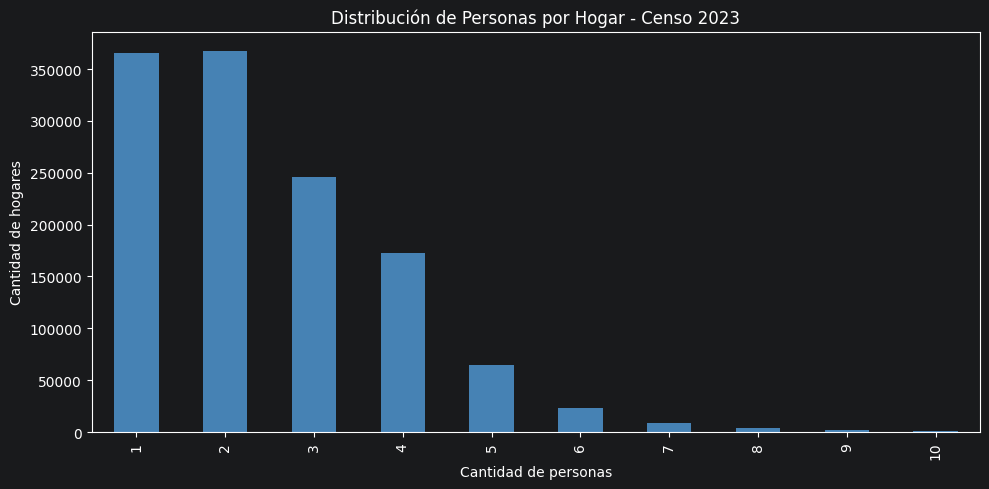

Mediana: 2.0
Media: 2.47
Moda: 2


In [8]:
# Distribución de personas por hogar
personas = df_raw['HOGPR01_CON_RRAA']
# Filtrar outliers extremos (codigos especiales)
personas_validos = personas[personas < 11]

fig, ax = plt.subplots(figsize=(10, 5))
personas_validos.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Distribución de Personas por Hogar - Censo 2023')
ax.set_xlabel('Cantidad de personas')
ax.set_ylabel('Cantidad de hogares')
plt.tight_layout()
plt.show()

print(f'Mediana: {personas_validos.median()}')
print(f'Media: {personas_validos.mean():.2f}')
print(f'Moda: {personas_validos.mode()[0]}')

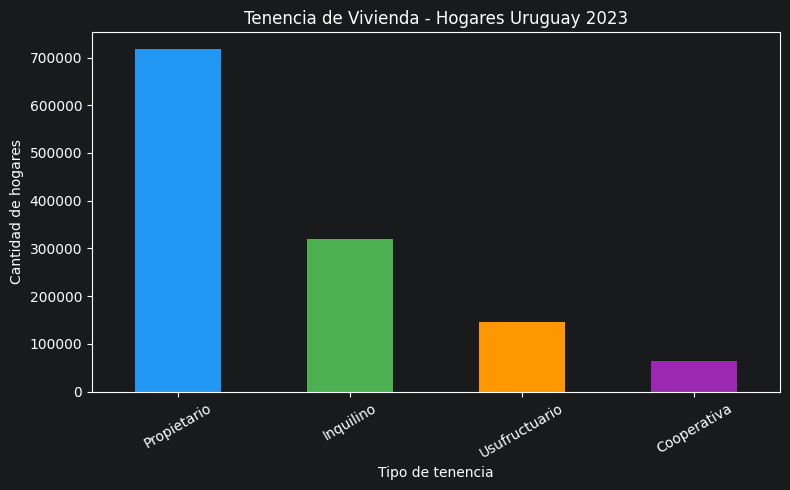

In [9]:
# Distribución por tenencia de vivienda
tenencia_counts = df_raw['HOGTE01'].value_counts()
# Solo valores válidos (1-4)
tenencia_validos = tenencia_counts[tenencia_counts.index.isin([1,2,3,4])]
tenencia_labels = {1: 'Propietario', 2: 'Cooperativa', 3: 'Inquilino', 4: 'Usufructuario'}

fig, ax = plt.subplots(figsize=(8, 5))
tenencia_validos.rename(index=tenencia_labels).plot(kind='bar', ax=ax, color=['#2196F3','#4CAF50','#FF9800','#9C27B0'])
ax.set_title('Tenencia de Vivienda - Hogares Uruguay 2023')
ax.set_xlabel('Tipo de tenencia')
ax.set_ylabel('Cantidad de hogares')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

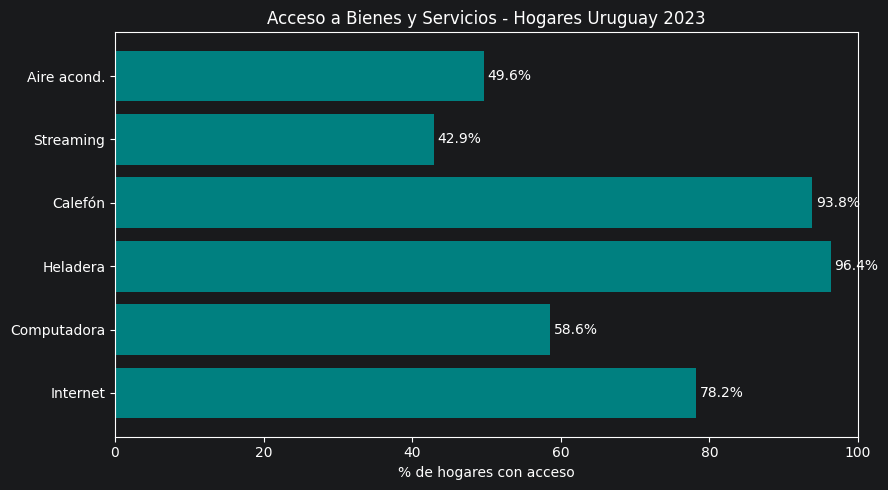

In [10]:
# Acceso a servicios básicos
servicios = {
    'Internet': df_raw['HOGCE11'],
    'Computadora': df_raw['HOGCE28'],
    'Heladera': df_raw['HOGCE03'],
    'Calefón': df_raw['HOGCE27'],
    'Streaming': df_raw['HOGCE22'],
    'Aire acond.': df_raw['HOGCE17'],
}

acceso_pct = {}
for nombre, col in servicios.items():
    validos = col[col.isin([1, 2])]
    pct_si = (validos == 1).sum() / len(validos) * 100
    acceso_pct[nombre] = pct_si

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(list(acceso_pct.keys()), list(acceso_pct.values()), color='teal')
ax.set_xlabel('% de hogares con acceso')
ax.set_title('Acceso a Bienes y Servicios - Hogares Uruguay 2023')
ax.set_xlim(0, 100)
for i, v in enumerate(acceso_pct.values()):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

Correlación entre habitaciones y personas por hogar:
                   HOGHD00   HOGHD01  HOGPR01_CON_RRAA
HOGHD00           1.000000  0.625884          0.255816
HOGHD01           0.625884  1.000000          0.528318
HOGPR01_CON_RRAA  0.255816  0.528318          1.000000


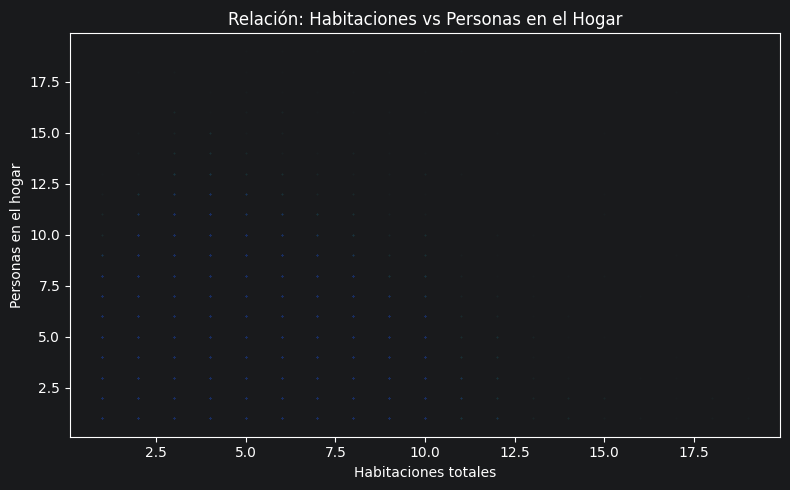

In [11]:
# Correlación entre habitaciones y personas en el hogar
hd = df_raw[['HOGHD00', 'HOGHD01', 'HOGPR01_CON_RRAA']].copy()
hd = hd[(hd['HOGHD00'] < 20) & (hd['HOGPR01_CON_RRAA'] < 20)]
hd = hd[~hd.isin([7777, 8888, 9898, 9999]).any(axis=1)]

print('Correlación entre habitaciones y personas por hogar:')
print(hd.corr())

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(hd['HOGHD00'], hd['HOGPR01_CON_RRAA'], alpha=0.01, color='steelblue', s=1)
ax.set_xlabel('Habitaciones totales')
ax.set_ylabel('Personas en el hogar')
ax.set_title('Relación: Habitaciones vs Personas en el Hogar')
plt.tight_layout()
plt.show()

## 3. Limpieza y Transformación del Dataset

In [12]:
df = df_raw.copy()

# Eliminar columna índice
df = df.drop(columns=['Unnamed: 0'])

# Renombrar columnas
rename_map = {
    'DEPARTAMENTO': 'departamento',
    'LOCALIDAD': 'localidad',
    'REGION_4': 'region',
    'AREA': 'area',
    'MUNICIPIO_PAIS': 'municipio',
    'TIPO_MUNICIPIO_PAIS': 'tipo_municipio',
    'VIVVO00': 'tipo_vivienda',
    'HOGTE01': 'tenencia_vivienda',
    'HOGHD00': 'habitaciones_totales',
    'HOGHD01': 'habitaciones_dormir',
    'HOGSC01': 'lugar_cocina',
    'HOGSC02': 'energia_cocina',
    'HOGCA01': 'energia_calefaccion',
    'HOGSH01': 'disponibilidad_bano',
    'HOGSH02': 'uso_bano',
    'HOGSH03': 'evacuacion_sanitaria',
    'HOGRS01': 'disposicion_residuos',
    'HOGCE27': 'tiene_termofon',
    'HOGCE26': 'tiene_colector_solar',
    'HOGCE03': 'tiene_heladera',
    'HOGCE04': 'tiene_secadora',
    'HOGCE17': 'tiene_aire_acond',
    'HOGCE17_1': 'cant_aires',
    'HOGCE28': 'tiene_computadora',
    'HOGCE11': 'tiene_internet',
    'HOGCE22': 'tiene_streaming',
    'HOGCE12_1': 'tiene_moto',
    'HOGCE13': 'cant_autos',
    'HOGMA01_1': 'tiene_perro',
    'HOGMA01_1_1': 'cant_perros',
    'HOGMA01_2': 'tiene_gato',
    'HOGMA01_2_1': 'cant_gatos',
    'HOGPR01_CON_RRAA': 'personas_en_hogar',
}
df = df.rename(columns=rename_map)

# Reemplazar códigos especiales por NaN
codigos_especiales = [7777, 8888, 9898, 99, 9999]
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].replace(codigos_especiales, np.nan)

# Eliminar columnas de identificación no útiles para análisis
df = df.drop(columns=['VIVID', 'HOGID', 'DIRECCION_ID', 'HOGTE02', 'HOGTE03', 'HOGSH02'], errors='ignore')

print(f'Shape tras limpieza: {df.shape}')

Shape tras limpieza: (1255204, 33)


In [13]:
# Agregar columnas descriptivas
dep_map = {
    1:'Montevideo', 2:'Artigas', 3:'Canelones', 4:'Cerro Largo',
    5:'Colonia', 6:'Durazno', 7:'Flores', 8:'Florida',
    9:'Lavalleja', 10:'Maldonado', 11:'Paysandú', 12:'Río Negro',
    13:'Rivera', 14:'Rocha', 15:'Salto', 16:'San José',
    17:'Soriano', 18:'Tacuarembó', 19:'Treinta y Tres'
}
df['departamento_nombre'] = df['departamento'].map(dep_map)
df['region_nombre'] = df['region'].map({1:'Montevideo',2:'Interior +5000 hab',3:'Interior -5000 hab',4:'Rural'})
df['area_nombre'] = df['area'].map({1:'Urbano', 2:'Rural'})
df['tenencia_nombre'] = df['tenencia_vivienda'].map({1:'Propietario',2:'Cooperativa',3:'Inquilino',4:'Usufructuario'})

# Convertir columnas binarias (1=Sí, 2=No) a booleano
cols_binarias = ['tiene_termofon','tiene_colector_solar','tiene_heladera','tiene_secadora',
                 'tiene_aire_acond','tiene_computadora','tiene_internet','tiene_streaming',
                 'tiene_moto','tiene_perro','tiene_gato']
for col in cols_binarias:
    df[col] = df[col].map({1: True, 2: False})

# Índice de confort: suma de bienes del hogar
df['indice_confort'] = (
    df['tiene_termofon'].astype(float) +
    df['tiene_heladera'].astype(float) +
    df['tiene_secadora'].astype(float) +
    df['tiene_aire_acond'].astype(float) +
    df['tiene_computadora'].astype(float) +
    df['tiene_internet'].astype(float) +
    df['tiene_streaming'].astype(float) +
    df['tiene_moto'].astype(float)
)

print('Columnas finales:')
print(df.columns.tolist())

Columnas finales:
['departamento', 'localidad', 'region', 'area', 'municipio', 'tipo_municipio', 'tipo_vivienda', 'tenencia_vivienda', 'disponibilidad_bano', 'uso_bano', 'evacuacion_sanitaria', 'lugar_cocina', 'habitaciones_totales', 'habitaciones_dormir', 'energia_cocina', 'energia_calefaccion', 'disposicion_residuos', 'tiene_termofon', 'tiene_colector_solar', 'tiene_heladera', 'tiene_secadora', 'tiene_aire_acond', 'cant_aires', 'tiene_computadora', 'tiene_internet', 'tiene_streaming', 'tiene_moto', 'cant_autos', 'tiene_perro', 'cant_perros', 'tiene_gato', 'cant_gatos', 'personas_en_hogar', 'departamento_nombre', 'region_nombre', 'area_nombre', 'tenencia_nombre', 'indice_confort']


In [14]:
# Vista final del dataframe limpio
df.head()

,departamento,localidad,region,area,municipio,tipo_municipio,tipo_vivienda,tenencia_vivienda,disponibilidad_bano,uso_bano,...,tiene_perro,cant_perros,tiene_gato,cant_gatos,personas_en_hogar,departamento_nombre,region_nombre,area_nombre,tenencia_nombre,indice_confort
0,1,20.0,1,1,Municipio B,C,1,2.0,1.0,1.0,...,False,NaN,False,NaN,2,Montevideo,Montevideo,Urbano,Cooperativa,6.0
1,1,20.0,1,1,Municipio B,C,1,2.0,1.0,1.0,...,False,NaN,False,NaN,2,Montevideo,Montevideo,Urbano,Cooperativa,4.0
2,1,20.0,1,1,Municipio B,C,1,2.0,1.0,1.0,...,True,2.0,True,2.0,2,Montevideo,Montevideo,Urbano,Cooperativa,5.0
3,1,20.0,1,1,Municipio B,C,1,2.0,1.0,1.0,...,False,NaN,False,NaN,1,Montevideo,Montevideo,Urbano,Cooperativa,4.0
4,1,20.0,1,1,Municipio B,C,1,2.0,1.0,1.0,...,False,NaN,False,NaN,4,Montevideo,Montevideo,Urbano,Cooperativa,6.0


In [15]:
# Estadísticas descriptivas del dataset limpio
df[['personas_en_hogar','habitaciones_totales','habitaciones_dormir','indice_confort','cant_autos']].describe()

,personas_en_hogar,habitaciones_totales,habitaciones_dormir,indice_confort,cant_autos
count,1.255204e+06,1.246626e+06,1.246626e+06,1.246627e+06,1.245767e+06
mean,2.507651e+00,3.141319e+00,1.895356e+00,4.610638e+00,6.081924e-01
std,5.220142e+00,1.332719e+00,8.367834e-01,1.677408e+00,7.060788e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2.000000e+00,1.000000e+00,3.000000e+00,0.000000e+00
50%,2.000000e+00,3.000000e+00,2.000000e+00,5.000000e+00,1.000000e+00
75%,3.000000e+00,4.000000e+00,2.000000e+00,6.000000e+00,1.000000e+00
max,4.673000e+03,5.000000e+01,3.900000e+01,8.000000e+00,8.900000e+01


## 4. Guardar Dataset Procesado

In [16]:
import os
os.makedirs('../data/processed', exist_ok=True)

output_path = '../data/processed/censo_hogares_2023_limpio.csv'
df.to_csv(output_path, index=False)

print(f'✅ Dataset guardado en: {output_path}')
print(f'   Filas: {len(df):,}  |  Columnas: {df.shape[1]}')

✅ Dataset guardado en: ../data/processed/censo_hogares_2023_limpio.csv
   Filas: 1,255,204  |  Columnas: 38
